# Model Evaluation and Preliminary Results

I am going to evaluate whether the features selected by the Pearson correlation, Spearman correlation, and Random Forest importance are useful for predicting county-level corn yield in later years. I will compare how models perform no selected features and the different selected features from the methods chosen. The years 2000-2020 will be the training and validation years while 2021-2025 will be the years for testing and evaluating. 

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor

## Load Dataset

In [2]:
df = pd.read_csv('../data/processed/corn_belt_yield_weather_soil.csv', dtype={'fips': str})

In [3]:
df.shape

(24644, 106)

In [4]:
df.head()

,state_name,state_alpha,state_ansi,county_ansi,fips,county_name,year,short_desc,unit_desc,statisticcat_desc,...,vp_mean_pa_m12,sand_pct_0_30cm,silt_pct_0_30cm,clay_pct_0_30cm,organic_matter_pct_0_30cm,ph_0_30cm,bulk_density_g_cm3_0_30cm,ksat_um_s_0_30cm,available_water_storage_cm_0_100cm,slope_pct
0,ILLINOIS,IL,17,11,17011,BUREAU,2025,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,357.549355,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
1,ILLINOIS,IL,17,11,17011,BUREAU,2024,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,462.975000,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
2,ILLINOIS,IL,17,11,17011,BUREAU,2023,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,614.017097,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
3,ILLINOIS,IL,17,11,17011,BUREAU,2022,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,393.786774,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
4,ILLINOIS,IL,17,11,17011,BUREAU,2021,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,504.136452,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624


## Split data into Training and Testing Sets

In [5]:
train = df[df['year'] <= 2020]
y_train = train['Value']

test = df[df['year'] > 2020]
y_test = test['Value']

In [6]:
train.shape

(20480, 106)

In [7]:
test.shape

(4164, 106)

In [8]:
df.shape == (train.shape[0] + test.shape[0], train.shape[1])

True

In [9]:
train['year'].min()

2000

In [10]:
train['year'].max()

2020

In [11]:
test['year'].min()

2021

In [12]:
test['year'].max()

2025

## Define Environmental Features

In [13]:
# weather
weather_cols = ['prcp_total_mm_m01', 'prcp_total_mm_m02', 'prcp_total_mm_m03', 'prcp_total_mm_m04', 'prcp_total_mm_m06', 'prcp_total_mm_m05', 'prcp_total_mm_m07', 'prcp_total_mm_m08', 'prcp_total_mm_m09', 'prcp_total_mm_m10', 'prcp_total_mm_m11', 'prcp_total_mm_m12', 'radiation_total_mj_m2_m01', 'radiation_total_mj_m2_m02', 'radiation_total_mj_m2_m03', 'radiation_total_mj_m2_m04', 'radiation_total_mj_m2_m05', 'radiation_total_mj_m2_m06', 'radiation_total_mj_m2_m07', 'radiation_total_mj_m2_m08', 'radiation_total_mj_m2_m09', 'radiation_total_mj_m2_m10', 'radiation_total_mj_m2_m11', 'radiation_total_mj_m2_m12', 'dayl_mean_s_m01', 'dayl_mean_s_m02', 'dayl_mean_s_m03', 'dayl_mean_s_m04', 'dayl_mean_s_m05', 'dayl_mean_s_m06', 'dayl_mean_s_m07', 'dayl_mean_s_m08', 'dayl_mean_s_m09', 'dayl_mean_s_m10', 'dayl_mean_s_m11', 'dayl_mean_s_m12', 'swe_mean_kg_m2_m01', 'swe_mean_kg_m2_m02', 'swe_mean_kg_m2_m03', 'swe_mean_kg_m2_m04', 'swe_mean_kg_m2_m05', 'swe_mean_kg_m2_m06', 'swe_mean_kg_m2_m07', 'swe_mean_kg_m2_m08', 'swe_mean_kg_m2_m09', 'swe_mean_kg_m2_m10', 'swe_mean_kg_m2_m11', 'swe_mean_kg_m2_m12', 'tmax_mean_c_m01', 'tmax_mean_c_m02', 'tmax_mean_c_m03', 'tmax_mean_c_m04', 'tmax_mean_c_m05', 'tmax_mean_c_m06', 'tmax_mean_c_m07', 'tmax_mean_c_m08', 'tmax_mean_c_m09', 'tmax_mean_c_m10', 'tmax_mean_c_m11', 'tmax_mean_c_m12', 'tmin_mean_c_m01', 'tmin_mean_c_m02', 'tmin_mean_c_m03', 'tmin_mean_c_m04', 'tmin_mean_c_m05', 'tmin_mean_c_m06', 'tmin_mean_c_m07', 'tmin_mean_c_m08', 'tmin_mean_c_m09', 'tmin_mean_c_m10', 'tmin_mean_c_m11', 'tmin_mean_c_m12', 'vp_mean_pa_m01', 'vp_mean_pa_m02', 'vp_mean_pa_m03', 'vp_mean_pa_m04', 'vp_mean_pa_m05', 'vp_mean_pa_m06', 'vp_mean_pa_m07', 'vp_mean_pa_m08', 'vp_mean_pa_m09', 'vp_mean_pa_m10', 'vp_mean_pa_m11', 'vp_mean_pa_m12']

In [14]:
# soil
soil_cols = ['sand_pct_0_30cm', 'silt_pct_0_30cm', 'clay_pct_0_30cm', 'organic_matter_pct_0_30cm', 'ph_0_30cm', 'bulk_density_g_cm3_0_30cm', 'ksat_um_s_0_30cm', 'available_water_storage_cm_0_100cm', 'slope_pct']

In [15]:
# weather + soil
environment_cols = weather_cols + soil_cols

In [16]:
# context features
context_cols = ['year', 'latitude', 'longitude']

In [17]:
# target feature
target_col = "Value"

## Remove Constant Features

I have three columns with values of all zeros `swe_mean_kg_m2_m07`, `swe_mean_kg_m2_m08`, and `swe_mean_kg_m2_m09`. These are the snow water equivalent for July, August, and September. Snow doesn't happen in these months in our dataset, so it is best to remove these constant value featuers as it will mess with our correlations and machine learning algorithms later on.

In [18]:
unique_counts = train[environment_cols].nunique()
unique_counts

prcp_total_mm_m01                     10177
prcp_total_mm_m02                     10267
prcp_total_mm_m03                     11732
prcp_total_mm_m04                     12783
prcp_total_mm_m06                     13651
                                      ...  
ph_0_30cm                              1119
bulk_density_g_cm3_0_30cm              1119
ksat_um_s_0_30cm                       1119
available_water_storage_cm_0_100cm     1119
slope_pct                              1119
Length: 93, dtype: int64

In [19]:
constant_features = unique_counts[unique_counts == 1]
constant_features

swe_mean_kg_m2_m07    1
swe_mean_kg_m2_m08    1
swe_mean_kg_m2_m09    1
dtype: int64

In [20]:
len(environment_cols)

93

In [21]:
environment_cols = unique_counts[unique_counts > 1].index.tolist()
len(environment_cols)

90

## Pearson Correlations

In [22]:
pearson = train[environment_cols].corrwith(y_train, method='pearson')
pearson_results = pearson.to_frame(name='Pearson')

pearson_results['Pearson_abs'] = pearson.abs().to_frame()

pearson_results = pearson_results.sort_values('Pearson_abs', ascending=False)

top_pearson = pearson_results.head(15)
top_pearson

,Pearson,Pearson_abs
tmax_mean_c_m07,-0.312787,0.312787
available_water_storage_cm_0_100cm,0.298842,0.298842
radiation_total_mj_m2_m06,-0.295676,0.295676
tmax_mean_c_m08,-0.285611,0.285611
prcp_total_mm_m07,0.250252,0.250252
prcp_total_mm_m06,0.224031,0.224031
vp_mean_pa_m06,0.222869,0.222869
radiation_total_mj_m2_m05,-0.195680,0.195680
vp_mean_pa_m09,0.189245,0.189245
tmin_mean_c_m06,0.188767,0.188767


In [23]:
pearson_top_15_cols = top_pearson.index.tolist()
pearson_top_15_cols

['tmax_mean_c_m07',
 'available_water_storage_cm_0_100cm',
 'radiation_total_mj_m2_m06',
 'tmax_mean_c_m08',
 'prcp_total_mm_m07',
 'prcp_total_mm_m06',
 'vp_mean_pa_m06',
 'radiation_total_mj_m2_m05',
 'vp_mean_pa_m09',
 'tmin_mean_c_m06',
 'radiation_total_mj_m2_m07',
 'prcp_total_mm_m08',
 'tmin_mean_c_m09',
 'vp_mean_pa_m05',
 'slope_pct']

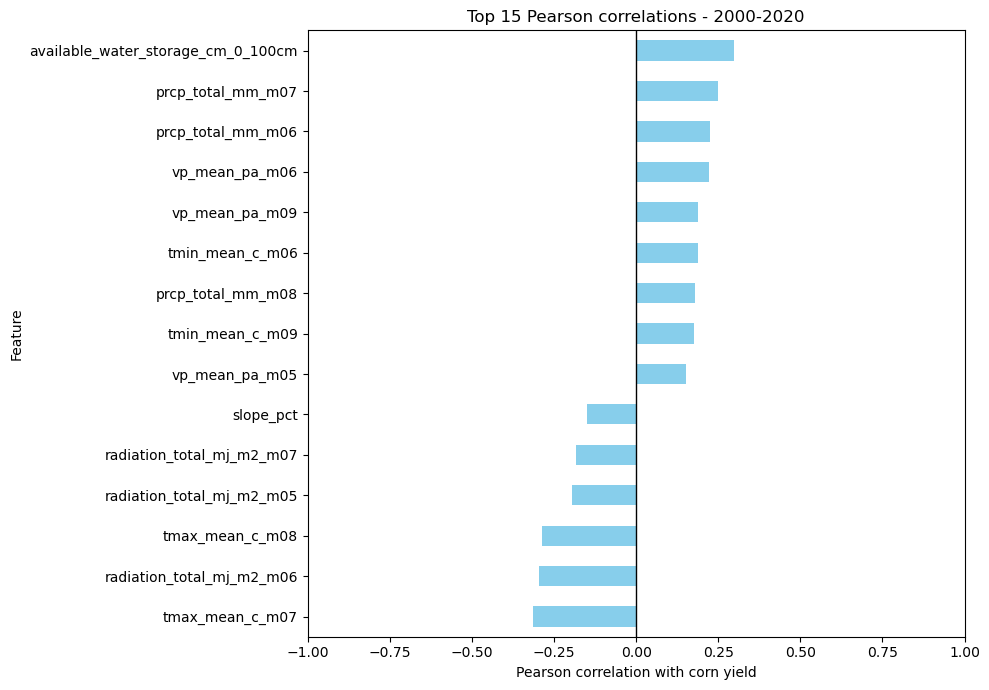

In [24]:
top_pearson['Pearson'].sort_values().plot.barh(figsize=(10, 7), color='skyblue')
plt.axvline(0, color="black", linewidth=1)
plt.xlim(-1,1)
plt.xlabel("Pearson correlation with corn yield")
plt.ylabel("Feature")
plt.title("Top 15 Pearson correlations - 2000-2020")
plt.tight_layout()
plt.show()

## Spearman Correlations

In [25]:
spearman = train[environment_cols].corrwith(y_train, method='spearman')
spearman_results = spearman.to_frame(name='Spearman')

spearman_results['Spearman_abs'] = spearman.abs().to_frame()

spearman_results = spearman_results.sort_values('Spearman_abs', ascending=False)

top_spearman = spearman_results.head(15)
top_spearman

,Spearman,Spearman_abs
available_water_storage_cm_0_100cm,0.333645,0.333645
tmax_mean_c_m08,-0.279351,0.279351
tmax_mean_c_m07,-0.266988,0.266988
prcp_total_mm_m07,0.253974,0.253974
radiation_total_mj_m2_m06,-0.242167,0.242167
prcp_total_mm_m06,0.233184,0.233184
prcp_total_mm_m08,0.186332,0.186332
vp_mean_pa_m06,0.180242,0.180242
radiation_total_mj_m2_m05,-0.172291,0.172291
slope_pct,-0.160421,0.160421


In [26]:
spearman_top_15_cols = top_spearman.index.tolist()
spearman_top_15_cols

['available_water_storage_cm_0_100cm',
 'tmax_mean_c_m08',
 'tmax_mean_c_m07',
 'prcp_total_mm_m07',
 'radiation_total_mj_m2_m06',
 'prcp_total_mm_m06',
 'prcp_total_mm_m08',
 'vp_mean_pa_m06',
 'radiation_total_mj_m2_m05',
 'slope_pct',
 'vp_mean_pa_m09',
 'tmax_mean_c_m01',
 'tmin_mean_c_m06',
 'tmin_mean_c_m09',
 'silt_pct_0_30cm']

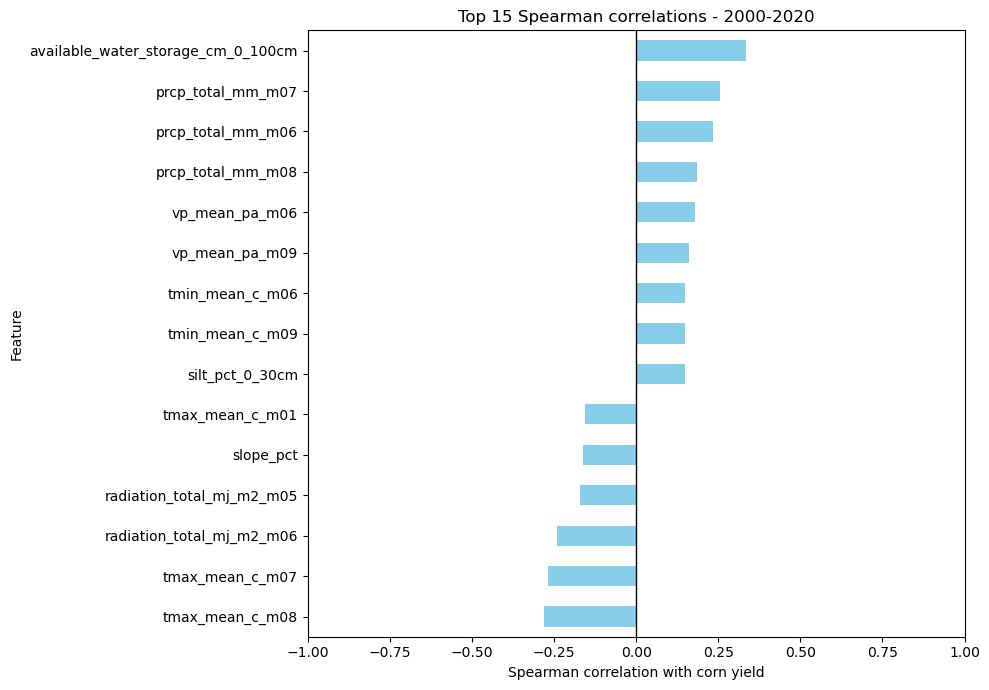

In [27]:
top_spearman['Spearman'].sort_values().plot.barh(figsize=(10, 7), color='skyblue')
plt.axvline(0, color="black", linewidth=1)
plt.xlim(-1,1)
plt.xlabel("Spearman correlation with corn yield")
plt.ylabel("Feature")
plt.title("Top 15 Spearman correlations - 2000-2020")
plt.tight_layout()
plt.show()

## Random Forest Feature Importance

In [28]:
X_train = train[environment_cols]
X_train.shape

(20480, 90)

In [29]:
forest = RandomForestRegressor(random_state=110)

In [30]:
forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [31]:
rf_results = pd.DataFrame({"Random Forest": forest.feature_importances_},index=X_train.columns)

rf_results = rf_results.sort_values("Random Forest", ascending=False)

top_rf = rf_results.head(15)
top_rf

,Random Forest
tmax_mean_c_m07,0.143764
available_water_storage_cm_0_100cm,0.097861
tmin_mean_c_m06,0.090538
tmax_mean_c_m08,0.075899
ksat_um_s_0_30cm,0.046194
vp_mean_pa_m06,0.045677
prcp_total_mm_m07,0.020806
tmin_mean_c_m09,0.017140
organic_matter_pct_0_30cm,0.015394
slope_pct,0.014244


In [32]:
rf_top_15_cols = top_rf.index.tolist()
rf_top_15_cols

['tmax_mean_c_m07',
 'available_water_storage_cm_0_100cm',
 'tmin_mean_c_m06',
 'tmax_mean_c_m08',
 'ksat_um_s_0_30cm',
 'vp_mean_pa_m06',
 'prcp_total_mm_m07',
 'tmin_mean_c_m09',
 'organic_matter_pct_0_30cm',
 'slope_pct',
 'bulk_density_g_cm3_0_30cm',
 'ph_0_30cm',
 'radiation_total_mj_m2_m03',
 'tmin_mean_c_m05',
 'clay_pct_0_30cm']

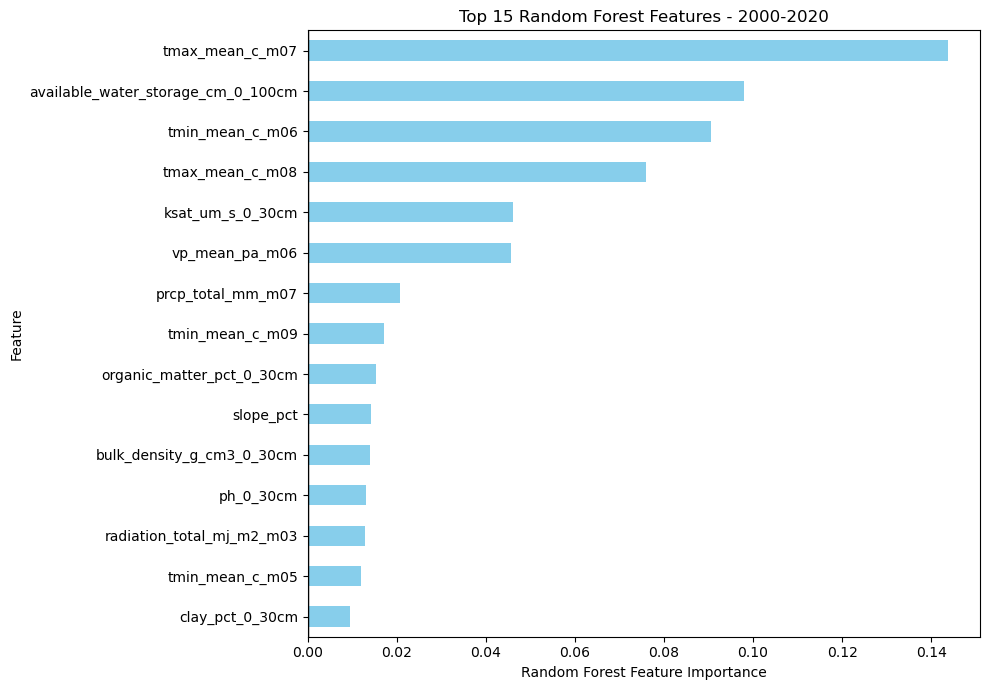

In [33]:
top_rf['Random Forest'].sort_values().plot.barh(figsize=(10, 7), color='skyblue')
plt.axvline(0, color="black", linewidth=1)
plt.xlim(left=0)
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features - 2000-2020")
plt.tight_layout()
plt.show()

## Preparing Prediction Inputs

For the datasets with the different featurs selected by the correlations and feature importance, I want to use all of the variables I can. This includes the year, latitude, and longitude which will give context to our prediction models.

In [34]:
all_input_cols = context_cols + environment_cols
pearson_input_cols = context_cols + pearson_top_15_cols
spearman_input_cols = context_cols + spearman_top_15_cols
rf_input_cols = context_cols + rf_top_15_cols

print("All features:", len(all_input_cols))
print("Pearson-selected:", len(pearson_input_cols))
print("Spearman-selected:", len(spearman_input_cols))
print("RF-selected:", len(rf_input_cols))

All features: 93
Pearson-selected: 18
Spearman-selected: 18
RF-selected: 18


In [35]:
X_train_all = train[all_input_cols].copy()
X_test_all = test[all_input_cols].copy()

In [36]:
X_train_pearson = train[pearson_input_cols].copy()
X_test_pearson = test[pearson_input_cols].copy()

In [37]:
X_train_spearman = train[spearman_input_cols].copy()
X_test_spearman = test[spearman_input_cols].copy()

In [38]:
X_train_rf = train[rf_input_cols].copy()
X_test_rf = test[rf_input_cols].copy()

## Baseline Prediction

A simple baseline model for each county's yield is created by taking the average of the yield from the years 2000-2020. This baseline is a reference for the prediciton models to compare to. 

In [39]:
county_mean_yield = train.groupby("fips")["Value"].mean()
county_mean_yield.head()

fips
17001    160.723810
17003    151.500000
17005    140.344444
17007    171.035000
17009    156.385000
Name: Value, dtype: float64

In [40]:
baseline_predictions = test["fips"].map(county_mean_yield)
baseline_predictions.head()

0    181.385714
1    181.385714
2    181.385714
3    181.385714
4    181.385714
Name: fips, dtype: float64

In [41]:
baseline_predictions.isna().sum()

6

In [42]:
state_mean_yield = train.groupby("state_alpha")["Value"].mean()
state_mean_yield

state_alpha
IA    169.206878
IL    162.081105
IN    155.599663
KS    119.286979
KY    134.186528
MI    130.453120
MN    154.764062
MO    129.324880
ND    103.224526
NE    157.446806
OH    146.791820
SD    114.443106
WI    141.313013
Name: Value, dtype: float64

In [43]:
state_baseline_predictions = test["state_alpha"].map(state_mean_yield)
baseline_predictions = baseline_predictions.fillna(state_baseline_predictions)

In [44]:
overall_mean_yield = train["Value"].mean()
baseline_predictions = baseline_predictions.fillna(overall_mean_yield)

In [45]:
print("Test observations:", len(test))
print("Baseline predictions:", len(baseline_predictions))
print("Missing predictions:", baseline_predictions.isna().sum())

Test observations: 4164
Baseline predictions: 4164
Missing predictions: 0


## Evaluate Baseline model

We will compare the baseline model with the actual yields from 2021-2025. We will use Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R^2. The lower the MAE and MSE the better while the higher R^2 is better.

In [46]:
# Calculate errors
baseline_errors = y_test - baseline_predictions
baseline_errors

0        44.514286
1        59.414286
2        42.114286
3        43.714286
4        22.114286
           ...    
24618    49.961905
24619    33.461905
24620    26.461905
24621    35.161905
24622    38.461905
Length: 4164, dtype: float64

In [47]:
# calculate Mean Absolute Error
baseline_mae = baseline_errors.abs().mean()
baseline_mae

31.920005963440627

In [48]:
# Calcualte  Mean Squared Error
baseline_mse = (baseline_errors ** 2).mean()
baseline_mse

1276.2439208571664

In [49]:
# Calcualte Root Mean Squared Error
baseline_rmse = np.sqrt(baseline_mse)
baseline_rmse

35.7245562723621

In [50]:
# Calculate R^2
baseline_squared_error = (baseline_errors ** 2).sum()
test_squared_variation = ((y_test - y_test.mean()) ** 2).sum()
baseline_r2 = 1 - (baseline_squared_error / test_squared_variation)
baseline_r2

0.08325164971775922

In [51]:
baseline_results = pd.DataFrame({
    "Model": ["Historical County Average Baseline"],
    "MAE": [baseline_mae],
    "MSE": [baseline_mse],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2]
})

baseline_results

,Model,MAE,MSE,RMSE,R2
0,Historical County Average Baseline,31.920006,1276.243921,35.724556,0.083252


The historical county average baseline has an `MAE` of `31.92` bushels per acre, `MSE` of `1276.24` squared bushels per squared acre, and an `RMSE` of `35.72` bushels per acre. The $R^2$ was `0.0833` whcih means about 8.3% less total squared error than redicting the test mean for every observation. 

A lower MAE, MSE, and RMSE correlate to a better prediction performance whcih a higher $R^2$ indicates better performance.

These are a reference for evaluating if the prediciton models improve with the feature selections compared to this baseline.

## Random Forest Prediction With All Features

In [52]:
print("Training inputs:", X_train_all.shape)
print("Test inputs:", X_test_all.shape)

Training inputs: (20480, 93)
Test inputs: (4164, 93)


In [53]:
# Create Model
rf_all = RandomForestRegressor(random_state=110)

In [54]:
# Train model
rf_all.fit(X_train_all, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [55]:
# Predictions
rf_all_predictions = rf_all.predict(X_test_all)

In [56]:
rf_all_predictions

array([200.977, 204.821, 203.489, ..., 161.412, 168.381, 160.529])

In [68]:
# turn this into a dataframe

In [58]:
rf_all_preview = pd.DataFrame({
    "Actual yield": y_test,
    "Predicted yield": rf_all_predictions
}, index=X_test_all.index)

rf_all_preview.head()

,Actual yield,Predicted yield
0,225.9,200.977
1,240.8,204.821
2,223.5,203.489
3,225.1,205.581
4,203.5,189.525


In [59]:
len(rf_all_predictions)

4164

### Evaluate Random Forest Model

In [60]:
rf_all_errors = (rf_all_preview["Actual yield"] - rf_all_preview["Predicted yield"])
rf_all_errors.head()

0    24.923
1    35.979
2    20.011
3    19.519
4    13.975
dtype: float64

In [61]:
rf_all_mae = rf_all_errors.abs().mean()
rf_all_mse = (rf_all_errors ** 2).mean()
rf_all_rmse = np.sqrt(rf_all_mse)
rf_all_squared_error = (rf_all_errors ** 2).sum()
rf_all_r2 = 1 - (rf_all_squared_error / test_squared_variation)

In [62]:
rf_all_results = pd.DataFrame({
    "Model": ["Random Forest All Features"],
    "MAE": [rf_all_mae],
    "MSE": [rf_all_mse],
    "RMSE": [rf_all_rmse],
    "R2": [rf_all_r2]
})

rf_all_results

,Model,MAE,MSE,RMSE,R2
0,Random Forest All Features,20.063974,598.511856,24.464502,0.570078


In [63]:
model_comparison = pd.concat([baseline_results, rf_all_results], ignore_index=True)
model_comparison

,Model,MAE,MSE,RMSE,R2
0,Historical County Average Baseline,31.920006,1276.243921,35.724556,0.083252
1,Random Forest All Features,20.063974,598.511856,24.464502,0.570078


## Random Forest Prediction With Pearson Correlation Selected Features

In [65]:
print("Training inputs:", X_train_pearson.shape)
print("Test inputs:", X_test_pearson.shape)

Training inputs: (20480, 18)
Test inputs: (4164, 18)


In [66]:
# Create Model
rf_pearson = RandomForestRegressor(random_state=110)

In [67]:
# Train model
rf_pearson.fit(X_train_pearson, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [71]:
# Predictions
rf_pearson_predictions = rf_pearson.predict(X_test_pearson)

In [72]:
rf_pearson_predictions

array([205.209, 201.129, 193.825, ..., 154.319, 160.128, 167.268])

In [73]:
rf_pearson_preview = pd.DataFrame({
    "Actual yield": y_test,
    "Predicted yield": rf_pearson_predictions
}, index=X_test_pearson.index)

rf_pearson_preview.head()

,Actual yield,Predicted yield
0,225.9,205.209
1,240.8,201.129
2,223.5,193.825
3,225.1,201.452
4,203.5,199.773


In [74]:
len(rf_pearson_predictions)

4164

### Evaluate Random Forest Model

In [75]:
rf_pearson_errors = (rf_pearson_preview["Actual yield"] - rf_pearson_preview["Predicted yield"])
rf_pearson_errors.head()

0    20.691
1    39.671
2    29.675
3    23.648
4     3.727
dtype: float64

In [76]:
rf_pearson_mae = rf_pearson_errors.abs().mean()
rf_pearson_mse = (rf_pearson_errors ** 2).mean()
rf_pearson_rmse = np.sqrt(rf_pearson_mse)
rf_pearson_squared_error = (rf_pearson_errors ** 2).sum()
rf_pearson_r2 = 1 - (rf_pearson_squared_error / test_squared_variation)

In [77]:
rf_pearson_results = pd.DataFrame({
    "Model": ["Random Forest Pearson Features"],
    "MAE": [rf_pearson_mae],
    "MSE": [rf_pearson_mse],
    "RMSE": [rf_pearson_rmse],
    "R2": [rf_pearson_r2]
})

rf_pearson_results

,Model,MAE,MSE,RMSE,R2
0,Random Forest Pearson Features,18.633575,524.448658,22.900844,0.623279


In [79]:
model_comparison = pd.concat([baseline_results, rf_all_results, rf_pearson_results], ignore_index=True)
model_comparison

,Model,MAE,MSE,RMSE,R2
0,Historical County Average Baseline,31.920006,1276.243921,35.724556,0.083252
1,Random Forest All Features,20.063974,598.511856,24.464502,0.570078
2,Random Forest Pearson Features,18.633575,524.448658,22.900844,0.623279


## Random Forest Prediction With Spearman Correlation Selected Features

In [80]:
print("Training inputs:", X_train_spearman.shape)
print("Test inputs:", X_test_spearman.shape)

Training inputs: (20480, 18)
Test inputs: (4164, 18)


In [81]:
# Create Model
rf_spearman = RandomForestRegressor(random_state=110)

In [82]:
# Train model
rf_spearman.fit(X_train_spearman, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [84]:
# Predictions
rf_spearman_predictions = rf_spearman.predict(X_test_spearman)

In [85]:
rf_spearman_predictions

array([201.437, 201.984, 194.333, ..., 154.745, 161.415, 166.896])

In [86]:
rf_spearman_preview = pd.DataFrame({
    "Actual yield": y_test,
    "Predicted yield": rf_spearman_predictions
}, index=X_test_spearman.index)

rf_spearman_preview.head()

,Actual yield,Predicted yield
0,225.9,201.437
1,240.8,201.984
2,223.5,194.333
3,225.1,205.069
4,203.5,204.550


In [87]:
len(rf_spearman_predictions)

4164

### Evaluate Random Forest Model

In [89]:
rf_spearman_errors = (rf_spearman_preview["Actual yield"] - rf_spearman_preview["Predicted yield"])
rf_spearman_errors.head()

0    24.463
1    38.816
2    29.167
3    20.031
4    -1.050
dtype: float64

In [95]:
rf_spearman_mae = rf_spearman_errors.abs().mean()
rf_spearman_mse = (rf_spearman_errors ** 2).mean()
rf_spearman_rmse = np.sqrt(rf_spearman_mse)
rf_spearman_squared_error = (rf_spearman_errors ** 2).sum()
rf_spearman_r2 = 1 - (rf_spearman_squared_error / test_squared_variation)

In [96]:
rf_spearman_results = pd.DataFrame({
    "Model": ["Random Forest Spearman Features"],
    "MAE": [rf_spearman_mae],
    "MSE": [rf_spearman_mse],
    "RMSE": [rf_spearman_rmse],
    "R2": [rf_spearman_r2]
})

rf_spearman_results

,Model,MAE,MSE,RMSE,R2
0,Random Forest Spearman Features,18.463086,514.95202,22.692554,0.630101


In [97]:
model_comparison = pd.concat([baseline_results, rf_all_results, rf_pearson_results, rf_spearman_results], ignore_index=True)
model_comparison

,Model,MAE,MSE,RMSE,R2
0,Historical County Average Baseline,31.920006,1276.243921,35.724556,0.083252
1,Random Forest All Features,20.063974,598.511856,24.464502,0.570078
2,Random Forest Pearson Features,18.633575,524.448658,22.900844,0.623279
3,Random Forest Spearman Features,18.463086,514.952020,22.692554,0.630101


## Random Forest Prediction With RF Feature Importance Selected Features

In [98]:
print("Training inputs:", X_train_rf.shape)
print("Test inputs:", X_test_rf.shape)

Training inputs: (20480, 18)
Test inputs: (4164, 18)


In [99]:
# Create Model
rf_selected = RandomForestRegressor(random_state=110)

In [100]:
# Train model
rf_selected.fit(X_train_rf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [103]:
# Predictions
rf_selected_predictions = rf_selected.predict(X_test_rf)

In [104]:
rf_selected_predictions

array([199.976, 203.223, 201.205, ..., 166.383, 167.139, 161.51 ])

In [105]:
rf_selected_preview = pd.DataFrame({
    "Actual yield": y_test,
    "Predicted yield": rf_selected_predictions
}, index=X_test_rf.index)

rf_selected_preview.head()

,Actual yield,Predicted yield
0,225.9,199.976
1,240.8,203.223
2,223.5,201.205
3,225.1,202.900
4,203.5,199.311


In [106]:
len(rf_selected_predictions)

4164

### Evaluate Random Forest Model

In [107]:
rf_selected_errors = (rf_selected_preview["Actual yield"] - rf_selected_preview["Predicted yield"])
rf_selected_errors.head()

0    25.924
1    37.577
2    22.295
3    22.200
4     4.189
dtype: float64

In [108]:
rf_selected_mae = rf_selected_errors.abs().mean()
rf_selected_mse = (rf_selected_errors ** 2).mean()
rf_selected_rmse = np.sqrt(rf_selected_mse)
rf_selected_squared_error = (rf_selected_errors ** 2).sum()
rf_selected_r2 = 1 - (rf_selected_squared_error / test_squared_variation)

In [110]:
rf_selected_results = pd.DataFrame({
    "Model": ["Random Forest Selected Features"],
    "MAE": [rf_selected_mae],
    "MSE": [rf_selected_mse],
    "RMSE": [rf_selected_rmse],
    "R2": [rf_selected_r2]
})

rf_selected_results

,Model,MAE,MSE,RMSE,R2
0,Random Forest Selected Features,18.358837,505.138407,22.475284,0.63715


In [111]:
model_comparison = pd.concat([baseline_results, rf_all_results, rf_pearson_results, rf_spearman_results, rf_selected_results], ignore_index=True)
model_comparison

,Model,MAE,MSE,RMSE,R2
0,Historical County Average Baseline,31.920006,1276.243921,35.724556,0.083252
1,Random Forest All Features,20.063974,598.511856,24.464502,0.570078
2,Random Forest Pearson Features,18.633575,524.448658,22.900844,0.623279
3,Random Forest Spearman Features,18.463086,514.952020,22.692554,0.630101
4,Random Forest Selected Features,18.358837,505.138407,22.475284,0.637150
